In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [2]:
# Load the dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Create a DataFrame
data = pd.DataFrame(X, columns=breast_cancer.feature_names)
data['target'] = y

In [3]:
print(data.head())
print(data.info())
print(data.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [4]:
print(data.isnull().sum())
print(data.duplicated().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
0


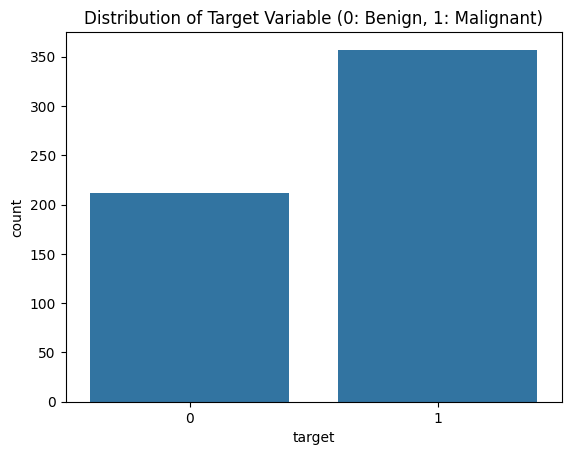

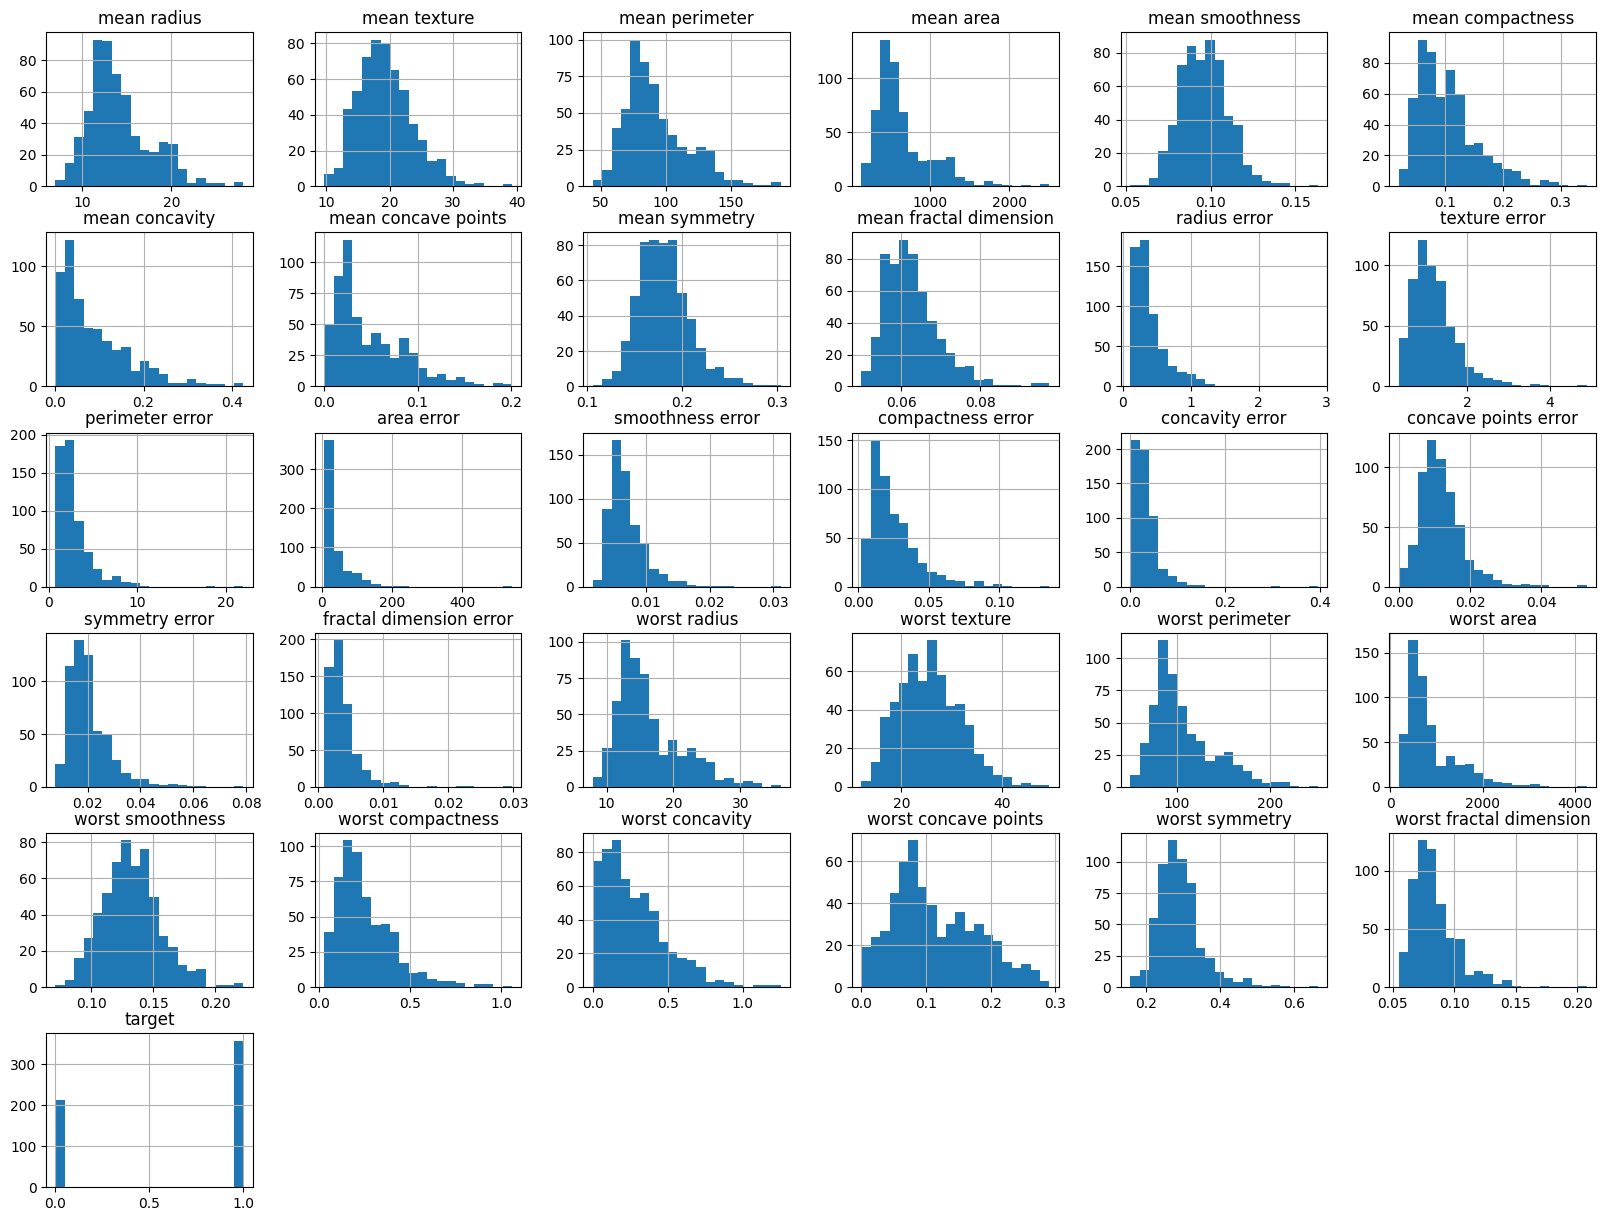

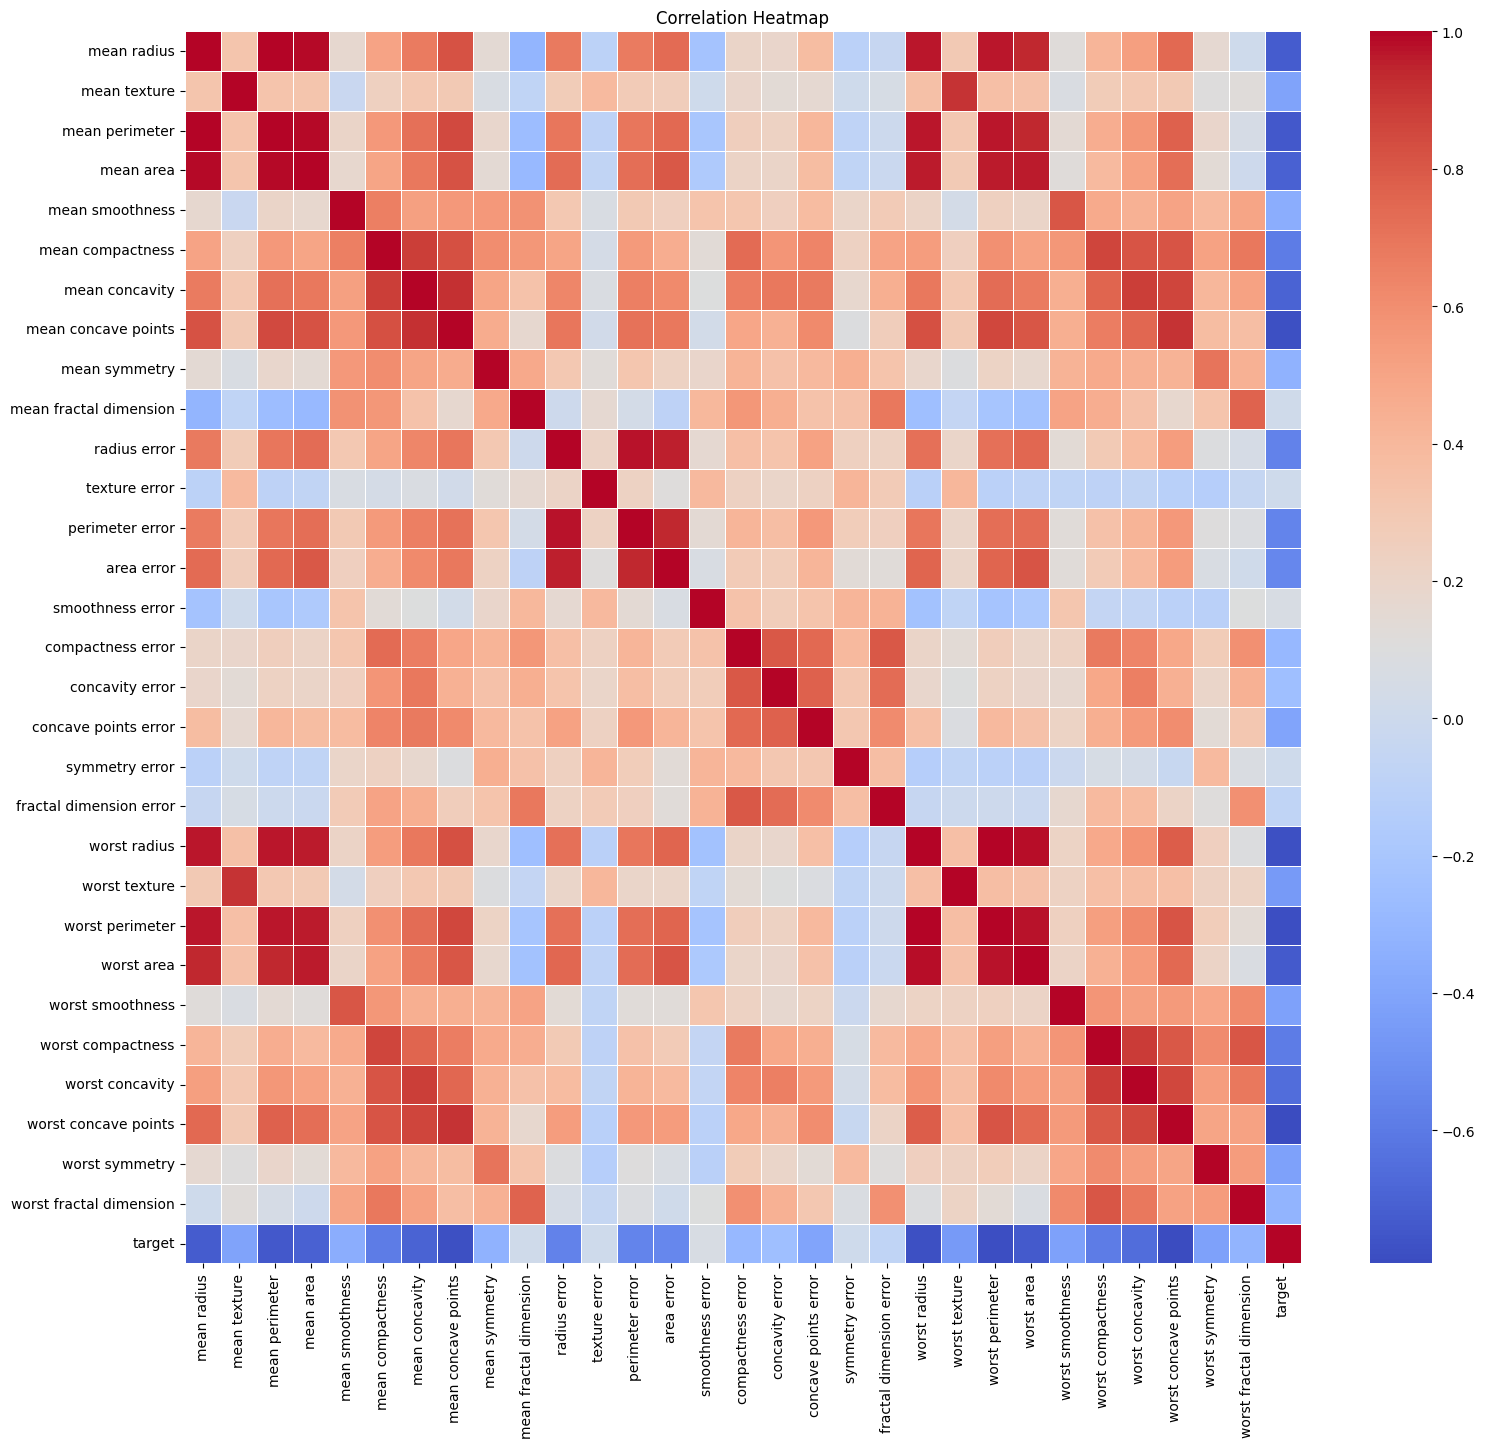

In [5]:
# Plot distribution of target variable
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable (0: Benign, 1: Malignant)')
plt.show()

# Histogram for features
data.hist(bins=20, figsize=(20, 15))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(18, 16))
corr = data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [6]:
# Identify features with strong correlation to target
cor_target = abs(corr["target"])
relevant_features = cor_target[cor_target > 0.5]
print(relevant_features)

mean radius             0.730029
mean perimeter          0.742636
mean area               0.708984
mean compactness        0.596534
mean concavity          0.696360
mean concave points     0.776614
radius error            0.567134
perimeter error         0.556141
area error              0.548236
worst radius            0.776454
worst perimeter         0.782914
worst area              0.733825
worst compactness       0.590998
worst concavity         0.659610
worst concave points    0.793566
target                  1.000000
Name: target, dtype: float64


### Dimensionality Reduction
We could consider techniques like Principal Component Analysis (PCA) to reduce the feature space.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

### Data Splitting:
We split the data into training and testing sets.

In [8]:
from sklearn.model_selection import train_test_split

# Using a subset of features based on correlation (Optional)
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness',
                     'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']

X_train, X_test, y_train, y_test = train_test_split(data[selected_features], data['target'], test_size=0.2, random_state=42)

Logistic Regression


In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

Support Vector Machine (SVC)

In [10]:
from sklearn.svm import SVC

svc_model = SVC(kernel='linear', random_state=42)
svc_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

Random Forest Classifier

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Gradient Boosting Classifier

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

### Model Evaluation

Evaluate each model using appropriate metrics, such as accuracy, precision, recall, and F1-score.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": lr_model,
    "SVC": svc_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbc_model
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-----------")

Model: Logistic Regression
Accuracy: 0.9386
Precision: 0.9444
Recall: 0.9577
F1 Score: 0.9510
Confusion Matrix:
[[39  4]
 [ 3 68]]
-----------
Model: SVC
Accuracy: 0.9386
Precision: 0.9571
Recall: 0.9437
F1 Score: 0.9504
Confusion Matrix:
[[40  3]
 [ 4 67]]
-----------
Model: Random Forest
Accuracy: 0.9474
Precision: 0.9577
Recall: 0.9577
F1 Score: 0.9577
Confusion Matrix:
[[40  3]
 [ 3 68]]
-----------
Model: Gradient Boosting
Accuracy: 0.9561
Precision: 0.9583
Recall: 0.9718
F1 Score: 0.9650
Confusion Matrix:
[[40  3]
 [ 2 69]]
-----------


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



In [15]:
# Collect metrics for each model
models = {
    "Logistic Regression": lr_model,
    "SVC": svc_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbc_model
}

metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "True Positive": [],
    "False Positive": [],
    "True Negative": [],
    "False Negative": []
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    metrics["Model"].append(model_name)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))
    metrics["F1 Score"].append(f1_score(y_test, y_pred))
    metrics["True Positive"].append(cm[1, 1])
    metrics["False Positive"].append(cm[0, 1])
    metrics["True Negative"].append(cm[0, 0])
    metrics["False Negative"].append(cm[1, 0])

df_metrics = pd.DataFrame(metrics)


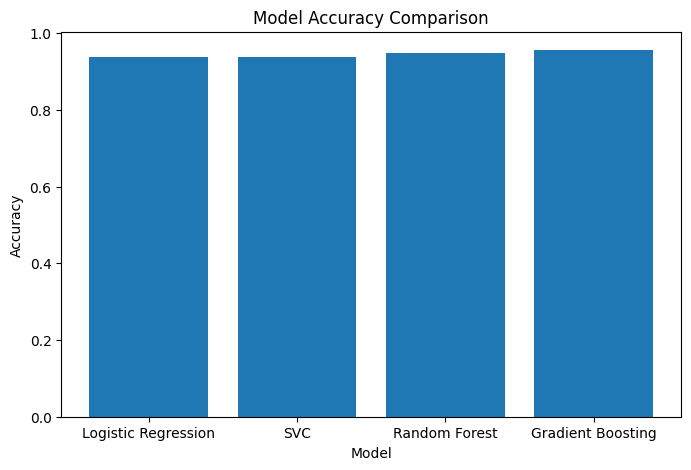

In [16]:
# 1. Bar plot for Accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

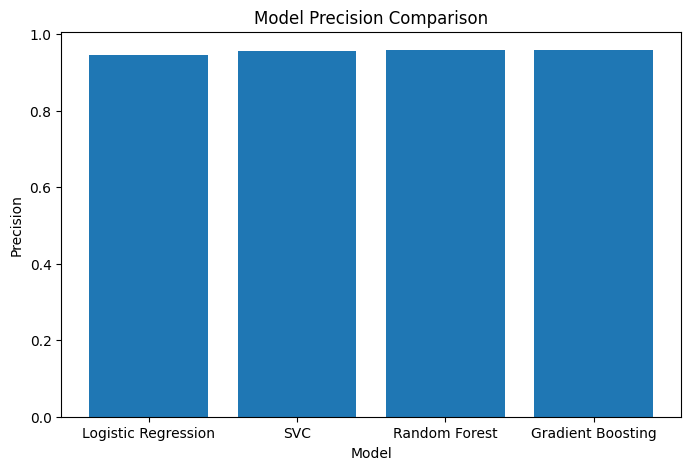

In [17]:
# 2. Bar plot for Precision comparison
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["Precision"])
plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("Model")
plt.show()

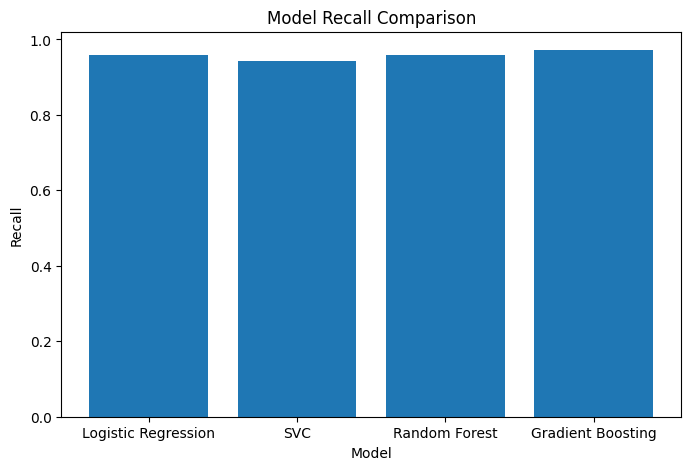

In [18]:
# 3. Bar plot for Recall comparison
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["Recall"])
plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Model")
plt.show()

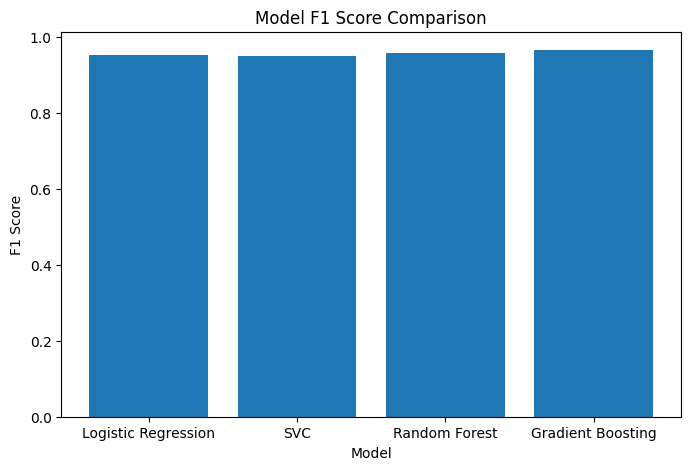

In [19]:
# 4. Bar plot for F1 Score comparison
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.show()

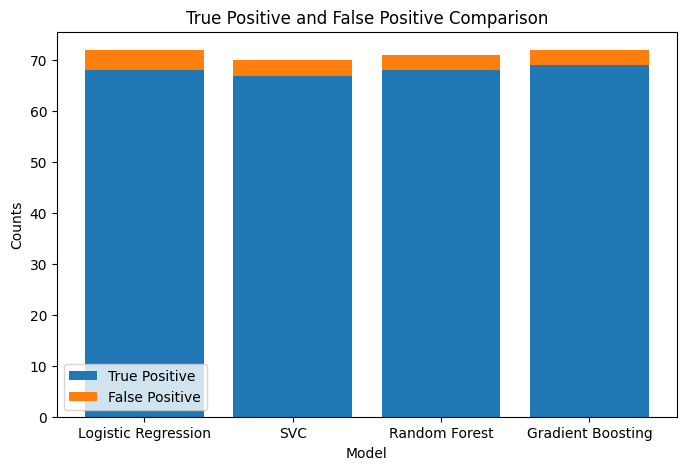

In [20]:
# 5. Stacked bar plot for True Positive and False Positive
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["True Positive"], label="True Positive")
plt.bar(df_metrics["Model"], df_metrics["False Positive"], bottom=df_metrics["True Positive"], label="False Positive")
plt.title("True Positive and False Positive Comparison")
plt.ylabel("Counts")
plt.xlabel("Model")
plt.legend()
plt.show()

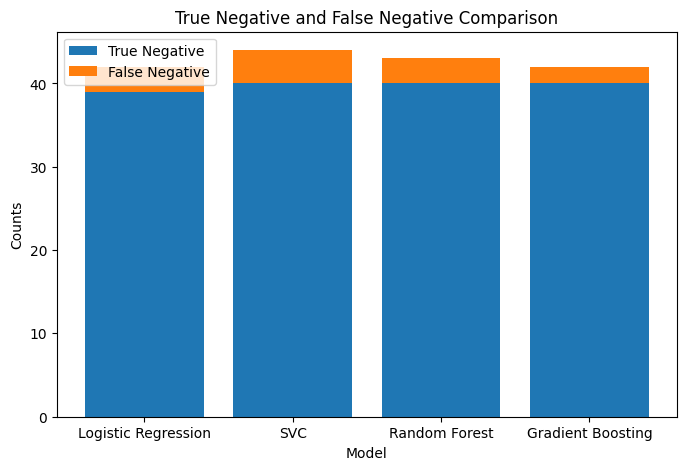

In [21]:
# 6. Stacked bar plot for True Negative and False Negative
plt.figure(figsize=(8, 5))
plt.bar(df_metrics["Model"], df_metrics["True Negative"], label="True Negative")
plt.bar(df_metrics["Model"], df_metrics["False Negative"], bottom=df_metrics["True Negative"], label="False Negative")
plt.title("True Negative and False Negative Comparison")
plt.ylabel("Counts")
plt.xlabel("Model")
plt.legend()
plt.show()

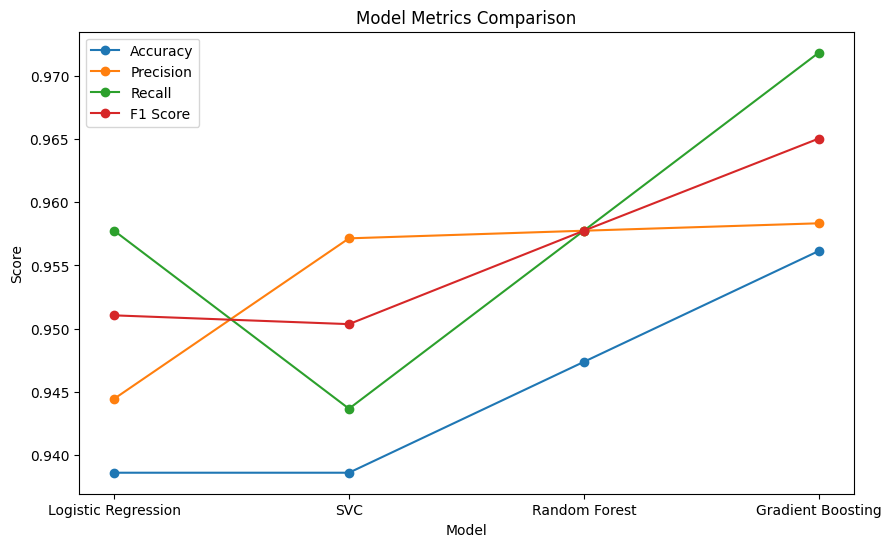

In [22]:
# 7. Line plot for Accuracy, Precision, Recall, and F1 Score
plt.figure(figsize=(10, 6))
for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    plt.plot(df_metrics["Model"], df_metrics[metric], marker='o', label=metric)
plt.title("Model Metrics Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend()
plt.show()

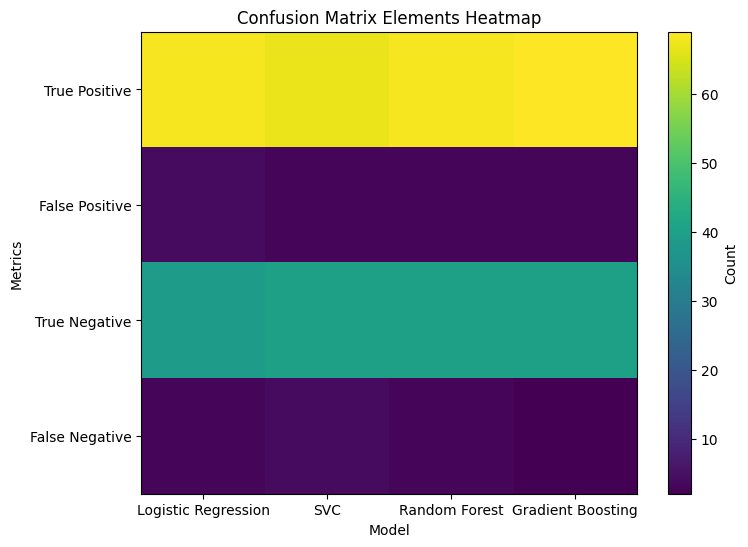

In [23]:
# 8. Heatmap for confusion matrix elements (TP, FP, TN, FN)
confusion_elements = df_metrics[["True Positive", "False Positive", "True Negative", "False Negative"]].T
plt.figure(figsize=(8, 6))
plt.imshow(confusion_elements, cmap="viridis", aspect='auto')
plt.colorbar(label="Count")
plt.title("Confusion Matrix Elements Heatmap")
plt.xticks(ticks=np.arange(len(df_metrics["Model"])), labels=df_metrics["Model"])
plt.yticks(ticks=np.arange(len(confusion_elements)), labels=confusion_elements.index)
plt.ylabel("Metrics")
plt.xlabel("Model")
plt.show()

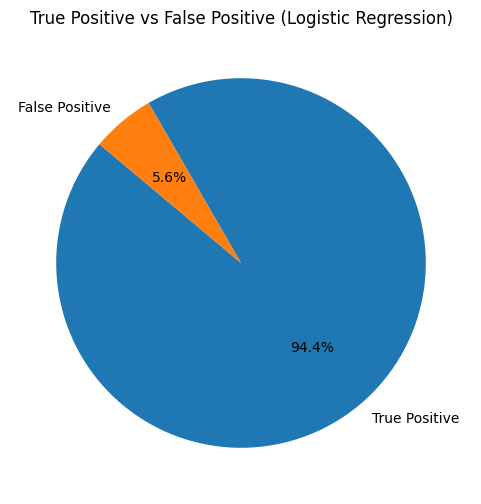

In [24]:
# 9. Pie chart for True Positive and False Positive (example for one model)
plt.figure(figsize=(6, 6))
tp_fp = [df_metrics["True Positive"][0], df_metrics["False Positive"][0]]
labels = ["True Positive", "False Positive"]
plt.pie(tp_fp, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("True Positive vs False Positive (Logistic Regression)")
plt.show()

In [26]:
# 10. Radar chart for model metrics
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

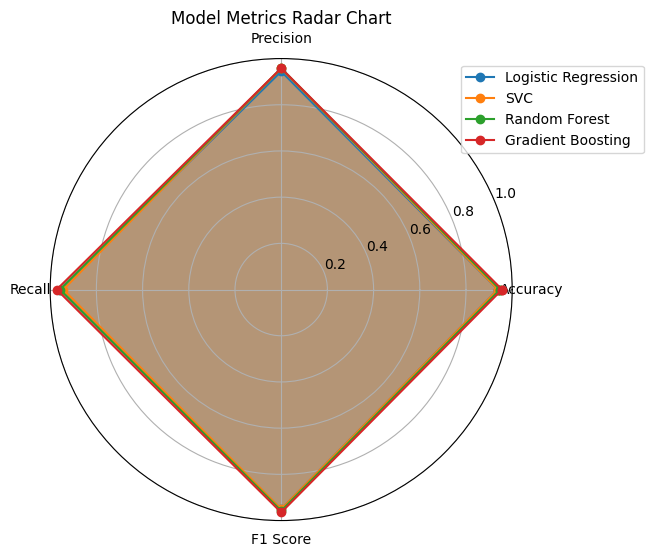

In [27]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, row in df_metrics.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    ax.plot(angles, values, marker='o', label=row["Model"])
    ax.fill(angles, values, alpha=0.25)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Model Metrics Radar Chart")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.show()

Best parameters for Random Forest: {'max_depth': 8, 'n_estimators': 200}
Best score for Random Forest: 0.9362637362637363
